(04-24-microstructuur)=

# Kyle, Glosten-Milgrom en liquiditeit

```{admonition} Waar we zijn in het verhaal
:class: important

**Jaartal.** 1984–2015, van Roll's impliciete spread en de modellen van Kyle en
Glosten-Milgrom tot de liquiditeitsfactoren en de wapenwedloop van de
hoogfrequente handel.

**Wat we al weten.** In [](#02-06-efficiente-markten) zagen we dat een volledig
informatieve prijs geen evenwicht kan zijn als informatie geld kost
(Grossman-Stiglitz), en in [](#02-07-event-studies) dat de halfwaardetijd van
publiek nieuws met elke verfijning van de meetlat kromp. [](#04-23-behavioral)
liet zien dat noise traders prijzen van hun waarde kunnen wegduwen en dat
arbitrage daar grenzen aan heeft. Wat ontbrak, was een model van het
*handelsmechanisme* zelf: wie zet de prijs, en wat weet die over wie er tegenover
hem staat?

**Welke vraag staat open.** Hoe komt private informatie via de handel in de
prijs, wat kost het om te handelen tegen iemand die meer weet, en wordt die kost
in verwachte rendementen geprijsd?
```

## Overzicht

Tot het midden van de jaren tachtig was de prijs in de asset pricing een getal
dat "de markt" zette. Het CAPM, de APT en de consumptie-CAPM zeggen welke prijs
een activum in evenwicht moet hebben, maar niet hoe die prijs tot stand komt, en
ook niet waarom er twee prijzen zijn, een bied- en een laatkoers. Twee artikelen
uit 1985 vulden dat gat met één idee. {cite:t}`GlostenMilgrom1985` lieten zien
dat een concurrerende *market maker* (handelaar die altijd bereid is te kopen en
te verkopen) zonder kosten en zonder risicoaversie tóch een spread moet rekenen,
omdat een deel van zijn tegenpartijen beter geïnformeerd is. {cite:t}`Kyle1985`
liet zien hoe een insider zijn informatie strategisch doseert, verstopt achter
ongeïnformeerde order flow, en hoe de prijs die informatie geleidelijk opneemt.
Santa-Clara vat het samen: in deze modellen wordt de prijs gezet door een market
maker die weet dat sommige handelaren geïnformeerd zijn, *"and the bid–ask spread
is the price of that adverse selection"* {cite}`SantaClara2026`.

Dat maakt deze lecture een scharnierpunt. De microstructuurtheorie is een
*theorie-met-tests* in de oude zin: een expliciet evenwicht met scherpe,
gesloten voorspellingen ($\lambda = \sigma_v/2\sigma_u$, de helft van de
onzekerheid verdwijnt in de prijs, transactieprijzen zijn een martingaal). De
empirie die erop volgde, is van een ander soort. {cite:t}`Roll1984b` haalde een
spread uit de autocovariantie van koersen, {cite:t}`AmihudMendelson1986` en
{cite:t}`Amihud2002` vonden dat illiquide aandelen hogere rendementen opleveren,
en {cite:t}`PastorStambaugh2003` en {cite:t}`AcharyaPedersen2005` maakten van
liquiditeit een *risicofactor*. Dat laatste is een feit met concurrerende
verklaringen: een premie voor een risico dat in crises toeslaat, of een
vergoeding voor een kost die beleggers slecht inschatten. Santa-Clara's
stelling nummer negen in zijn lijst van wat we weten luidt: *"Liquidity is
priced, and it disappears when you need it"* {cite}`SantaClara2026`.

Aan het eind repliceren we op dagdata van vijftig grote Amerikaanse aandelen dat
illiquiditeit piekt in 2008 en maart 2020 en dat innovaties in illiquiditeit
samengaan met lage marktrendementen {cite}`Amihud2002`, en op de reeks van Pástor
en Stambaugh dat marktliquiditeit instort in de bekende crisismaanden.

In [1]:
import io

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
from scipy import stats

import hap
from hap import cache as hap_cache
from hap import data as hap_data
hap.plotting.setup()

rng = np.random.default_rng(20240101)

## Intuïtie: waarom zou dit waar zijn?

Stel je een handelaar voor die iedereen bedient die wil kopen of verkopen. De
meeste klanten handelen om redenen die niets met de waarde van het aandeel te maken
hebben: een pensioenfonds dat geld nodig heeft, een belegger die herbalanceert.
Een klein deel weet iets. De handelaar kan de groepen niet uit elkaar houden; hij
weet alleen dat een koopopdracht iets waarschijnlijker van iemand met goed nieuws
komt.

Daaruit volgt de spread. Als de handelaar aan elke koper verkoopt tegen de
gemiddelde waarde, verliest hij systematisch aan de geïnformeerde kopers: die
kopen juist wanneer het aandeel meer waard is. Hij moet dus verkopen tegen de
waarde *gegeven dat iemand wil kopen*, en kopen tegen de waarde *gegeven dat
iemand wil verkopen*. Het verschil is geen winstmarge en geen vergoeding voor
voorraadrisico; het is de verzekeringspremie die de ongeïnformeerde klanten
betalen voor het verlies dat de handelaar aan de geïnformeerde lijdt. Na elke
order werkt de handelaar zijn oordeel bij. Na een reeks kooporders gelooft hij in
goed nieuws, zijn koersen schuiven omhoog, en omdat hij steeds zekerder wordt,
wordt de spread kleiner. Informatie sijpelt zo via de handel in de prijs.

Kyle voegde de strategie van de insider toe. Een insider die precies weet wat een
aandeel waard is, wil zoveel mogelijk kopen, maar hoe meer hij koopt, hoe meer hij
de koers opdrijft en hoe meer hij zichzelf verraadt. Hij handelt dus gematigd, en
verstopt zijn orders tussen die van de ongeïnformeerde handelaren. Hoe meer ruis
er is, hoe agressiever hij kan handelen zonder op te vallen. In evenwicht is dat
zo precies in balans dat de prijs na één handelsronde de helft van zijn
informatie bevat, ongeacht hoeveel ruis er is. Mag hij over vele rondes handelen,
dan doseert hij zijn informatie zo dat de prijs haar gelijkmatig opneemt: elke
ronde komt er een even groot stuk bij, en aan het eind zit alles erin. De
ongeïnformeerde handelaren betalen de winst van de insider; de market maker
speelt quitte.

Wie de handelaar niet ziet, ziet de gevolgen in gewone dagkoersen: transacties die
tussen bied en laat heen en weer springen (Roll rekende daaruit de spread terug),
en koersen die bij weinig omzet veel bewegen (Amihud's maat).

En dan de stap naar asset pricing. Als handelen geld kost, eisen beleggers voor
illiquide aandelen een hoger rendement. Maar liquiditeit *verdwijnt* ook: in
oktober 1987, in de herfst van 1998 toen LTCM omviel (zie
[](#04-22-risk-management)), in 2008 en in maart 2020 werd handelen voor iedereen
tegelijk duur, precies toen beleggers moesten verkopen. Een aandeel dat juist dan
illiquide wordt of slecht rendeert, moet meer opleveren. Dat is Santa-Clara's
*fair-weather friend*: liquiditeit is *"abundant when nobody needs it and gone in
every crisis on record"* {cite}`SantaClara2026`.

## Toy-voorbeeld: één market maker, één order, één insider

### Glosten-Milgrom met één transactie

Een aandeel is morgen $V_H = 102$ of $V_L = 98$ waard, elk met kans $\tfrac12$.
Een fractie $\mu = 0{,}2$ van de handelaren kent de waarde; zij kopen als die
hoog is en verkopen als die laag is. De overige $80\%$ kopen of verkopen met kans
$\tfrac12$, los van de waarde. De market maker is risiconeutraal, heeft geen
kosten en maakt door concurrentie verwacht nul winst, dus zijn laatkoers is de
verwachte waarde *gegeven een kooporder*.

De kans op een kooporder als de waarde hoog is:
$P(\text{koop}\mid H) = 0{,}2 + 0{,}8\cdot\tfrac12 = 0{,}6$; als de waarde laag
is: $P(\text{koop}\mid L) = 0{,}8\cdot\tfrac12 = 0{,}4$. Onvoorwaardelijk
$P(\text{koop}) = \tfrac12(0{,}6) + \tfrac12(0{,}4) = 0{,}5$. Bayes geeft

$$
P(H \mid \text{koop}) = \frac{0{,}5\cdot 0{,}6}{0{,}5} = 0{,}6,
\qquad
P(H \mid \text{verkoop}) = \frac{0{,}5\cdot 0{,}4}{0{,}5} = 0{,}4 .
$$

Dus laat $= 0{,}6\cdot 102 + 0{,}4\cdot 98 = 100{,}40$ en bied
$= 0{,}4\cdot 102 + 0{,}6\cdot 98 = 99{,}60$. De spread is $0{,}80$, precies
$\mu(V_H - V_L) = 0{,}2\cdot 4$.

Na een kooporder gelooft de market maker $\pi_1 = 0{,}6$. De nieuwe
kooporderkans is $0{,}6\cdot0{,}6 + 0{,}4\cdot0{,}4 = 0{,}52$, dus
$P(H\mid\text{koop}) = 0{,}36/0{,}52 = 0{,}6923$ en de nieuwe laatkoers
$98 + 4\cdot0{,}6923 = 100{,}77$; na een verkooporder zou hij
$P(H\mid\text{verkoop}) = 0{,}24/0{,}48 = 0{,}5$ geloven, dus de biedkoers is
$100{,}00$. De spread is gekrompen tot $0{,}77$, en de verwachte volgende
transactieprijs is $0{,}52\cdot100{,}77 + 0{,}48\cdot100{,}00 = 100{,}40$: gelijk
aan de huidige transactieprijs. Dat is de martingaaleigenschap, in één regel
rekenwerk.

### Kyle met één handelsronde

De liquidatiewaarde $v$ van een aandeel is normaal verdeeld met verwachting
$p_0 = 50$ euro en standaarddeviatie $\sigma_v = 4$ euro. Noise traders sturen
samen een order $u$ met standaarddeviatie $\sigma_u = 10\,000$ aandelen. De insider
kent $v$; de market maker ziet alleen de totale order flow. De afleiding volgt in
[](#thm-microstructuur-kyle); de uitkomsten zijn

$$
\beta = \frac{\sigma_u}{\sigma_v} = \frac{10\,000}{4} = 2500 \text{ aandelen per euro},
\qquad
\lambda = \frac{\sigma_v}{2\sigma_u} = \frac{4}{20\,000} = 0{,}0002 \text{ euro per aandeel}.
$$

Een order van $10\,000$ aandelen verschuift de prijs dus $2$ euro. De verwachte
winst van de insider is $\tfrac12\sigma_v\sigma_u = 20\,000$ euro; de noise traders
verliezen samen verwacht precies $20\,000$ euro; de market maker verdient niets.
De restvariantie na de handel is $\sigma_v^2/2 = 8$, een standaarddeviatie van
$2{,}83$ euro in plaats van $4$.

Neem één realisatie: $v = 53$ en $u = -4000$. De insider koopt
$\beta(v-p_0) = 2500\cdot3 = 7500$ aandelen, de order flow is $7500 - 4000 = 3500$,
en de prijs wordt $50 + 0{,}0002\cdot3500 = 50{,}70$. De insider verdient
$7500\cdot(53-50{,}70) = 17\,250$; de noise traders, die per saldo $4000$ aandelen
verkochten tegen $50{,}70$, verliezen $4000\cdot2{,}30 = 9200$; de market maker,
die per saldo $3500$ aandelen verkocht, verliest $3500\cdot2{,}30 = 8050$. De som is
nul. Dat de market maker hier verliest, is toeval; gemiddeld over $u$ en $v$
speelt hij quitte.

In [2]:
def gm_quotes(pi, mu, v_high, v_low):
    """Bid and ask of a zero-profit Glosten-Milgrom market maker with belief pi = P(V = v_high)."""
    buy_h, buy_l = mu + (1 - mu) / 2, (1 - mu) / 2
    post_buy = pi * buy_h / (pi * buy_h + (1 - pi) * buy_l)
    post_sell = pi * (1 - buy_h) / (pi * (1 - buy_h) + (1 - pi) * (1 - buy_l))
    return v_low + (v_high - v_low) * post_sell, v_low + (v_high - v_low) * post_buy


V_H, V_L, MU = 102.0, 98.0, 0.2
bid0, ask0 = gm_quotes(0.5, MU, V_H, V_L)
pi1 = 0.5 * 0.6 / 0.5                                  # belief after one buy order
bid1, ask1 = gm_quotes(pi1, MU, V_H, V_L)
p_buy_next = pi1 * 0.6 + (1 - pi1) * 0.4
next_price = p_buy_next * ask1 + (1 - p_buy_next) * bid1
print("Glosten-Milgrom")
print(f"  bid = {bid0:.2f}, ask = {ask0:.2f}, spread = {ask0 - bid0:.2f} = mu (V_H - V_L) = {MU * (V_H - V_L):.2f}")
print(f"  na een koop: bid = {bid1:.2f}, ask = {ask1:.2f}, spread = {ask1 - bid1:.2f}")
print(f"  verwachte volgende transactieprijs = {next_price:.2f} (huidige: {ask0:.2f})")

sigma_v, sigma_u, p0 = 4.0, 10_000.0, 50.0
beta_k = sigma_u / sigma_v
lam_k = sigma_v / (2 * sigma_u)
v, u = 53.0, -4_000.0
theta = beta_k * (v - p0)
y = theta + u
p1 = p0 + lam_k * y
pnl = {"insider": theta * (v - p1), "noise traders": u * (v - p1), "market maker": -y * (v - p1)}
print("\nKyle, één ronde")
print(f"  beta = {beta_k:.0f} aandelen per euro, lambda = {lam_k:.4f} euro per aandeel")
print(f"  verwachte winst insider = {sigma_v * sigma_u / 2:,.0f}, restvariantie = {sigma_v**2 / 2:.1f}")
print(f"  realisatie: order insider = {theta:,.0f}, order flow = {y:,.0f}, prijs = {p1:.2f}")
print("  winst per partij:", {k: round(x) for k, x in pnl.items()}, " som =", round(sum(pnl.values())))

assert np.allclose([bid0, ask0, bid1, next_price], [99.60, 100.40, 100.00, 100.40])
assert np.isclose(ask1, 98 + 4 * 0.36 / 0.52)
assert np.isclose(p1, 50.70) and np.isclose(pnl["insider"], 17_250) and abs(sum(pnl.values())) < 1e-9
print("\nControle: code en handberekening komen overeen.")

Glosten-Milgrom
  bid = 99.60, ask = 100.40, spread = 0.80 = mu (V_H - V_L) = 0.80
  na een koop: bid = 100.00, ask = 100.77, spread = 0.77
  verwachte volgende transactieprijs = 100.40 (huidige: 100.40)

Kyle, één ronde
  beta = 2500 aandelen per euro, lambda = 0.0002 euro per aandeel
  verwachte winst insider = 20,000, restvariantie = 8.0
  realisatie: order insider = 7,500, order flow = 3,500, prijs = 50.70
  winst per partij: {'insider': 17250, 'noise traders': -9200, 'market maker': -8050}  som = 0

Controle: code en handberekening komen overeen.


## Theorie

### Opzet en notatie

In deze lecture gebruiken we de symbolen van Kyle: $\lambda$ is de prijsimpact van
order flow en $\beta$ de handelsintensiteit van de insider. Ze hebben hier dus
níet de betekenis uit de notatietabel (prijs van risico, subjectieve
discontofactor); waar de prijs van marktrisico terugkomt, bij Acharya-Pedersen,
schrijven we $\lambda_m$. De liquidatiewaarde van het aandeel noemen we $v$ (de
payoff $x_{t+1}$ uit de notatietabel), de order van de insider $\theta$ (Kyle
schrijft $x$, maar dat symbool is bij ons de payoff), de order van de noise
traders $u$ en de totale order flow $y = \theta + u$. Alle handelaren zijn
risiconeutraal, de rente is nul en er is geen discontering binnen de handelsdag.

Bij *Glosten-Milgrom* komen handelaren één voor één met één eenheid, en noemt de
market maker vooraf een bied- en laatkoers. Bij *Kyle* dienen alle handelaren
tegelijk een marktorder (een order zonder limietprijs) in en zet de market maker
één prijs op basis van de som. Het eerste model levert spreads, het tweede
prijsimpact; in beide dwingt concurrentie de prijs naar de voorwaardelijke
verwachting van $v$ gegeven de *order flow*.

### Glosten-Milgrom: de spread als adverse selectie

*Waarom zou dit waar zijn?* Een market maker die alle orders tegen dezelfde prijs
uitvoert, verliest aan geïnformeerde handelaren en wint niets terug van de rest.
Concurrentie laat hem geen winst over, maar ook geen verlies; de enige manier om
quitte te spelen is koersen zetten die al rekening houden met wat de order
verraadt. Omdat een koop goed nieuws suggereert en een verkoop slecht nieuws,
liggen de twee koersen uit elkaar. En omdat elke prijs een voorwaardelijke
verwachting is die met elke order wordt bijgewerkt, kan niemand met alleen de
publieke orderhistorie de volgende transactieprijs voorspellen.

:::{prf:theorem} Spread en martingaaleigenschap (Glosten-Milgrom)
:label: thm-microstructuur-gm

Laat $V \in \{V_L, V_H\}$, $\Delta V = V_H - V_L$, en laat $\pi = P(V = V_H \mid
\mathcal{F})$ het oordeel van de market maker zijn op basis van de publieke
orderhistorie $\mathcal{F}$. Een fractie $\mu$ van de handelaren is geïnformeerd;
de rest koopt of verkoopt met kans $\tfrac12$. Dan zijn de nulwinstkoersen
$a = \E[V \mid \mathcal{F}, \text{koop}]$ en $b = \E[V \mid \mathcal{F}, \text{verkoop}]$,
met spread

```{math}
:label: eq-microstructuur-gm-spread
a - b \;=\; \frac{4\mu\,\pi(1-\pi)}{1 - \mu^2 (2\pi - 1)^2}\;\Delta V ,
```

zodat $a - b = \mu\,\Delta V$ bij $\pi = \tfrac12$ en $a - b \to 0$ als
$\pi \to 0$ of $\pi \to 1$. De reeks transactieprijzen $p_n = \E[V \mid \mathcal{F}_n]$
is een martingaal ten opzichte van de publieke informatie:
$\E[p_{n+1} \mid \mathcal{F}_n] = p_n$.
:::

:::{prf:proof}
Schrijf $q_H = \tfrac{1+\mu}{2}$ en $q_L = \tfrac{1-\mu}{2}$ voor de kans op een
kooporder gegeven hoge respectievelijk lage waarde; $q_H + q_L = 1$ en
$q_H - q_L = \mu$. De kans op een koop is $D_k = \pi q_H + (1-\pi)q_L =
\tfrac12\bigl(1 + \mu(2\pi-1)\bigr)$ en op een verkoop $D_v = 1 - D_k =
\tfrac12\bigl(1 - \mu(2\pi-1)\bigr)$. Bayes geeft $a = V_L + \Delta V\,\pi q_H/D_k$ en
$b = V_L + \Delta V\,\pi q_L / D_v$, dus

$$
a - b = \Delta V\,\pi\,\frac{q_H D_v - q_L D_k}{D_k D_v}.
$$

De teller is $q_H(\pi q_L + (1-\pi)q_H) - q_L(\pi q_H + (1-\pi)q_L) =
(1-\pi)(q_H^2 - q_L^2) = (1-\pi)\mu$, omdat $q_H^2 - q_L^2 = (q_H-q_L)(q_H+q_L)$.
Met $D_kD_v = \tfrac14\bigl(1 - \mu^2(2\pi-1)^2\bigr)$ volgt
[](#eq-microstructuur-gm-spread).

Voor de martingaaleigenschap: de transactieprijs na order $n$ is $p_n =
\E[V\mid\mathcal{F}_n]$, want de laatkoers is de verwachting gegeven de historie
plus de koop, en na de koop is dat precies $\mathcal{F}_n$. Omdat
$\mathcal{F}_n \subseteq \mathcal{F}_{n+1}$, geeft de toreigenschap
$\E[p_{n+1}\mid\mathcal{F}_n] = \E\bigl[\E[V\mid\mathcal{F}_{n+1}]\mid\mathcal{F}_n\bigr]
= \E[V\mid\mathcal{F}_n] = p_n$. $\square$
:::

De spread bestaat zonder voorraadkosten of risicoaversie: het is zuiver
*adverse selection* (het verlies aan beter geïnformeerde tegenpartijen), het
uitgangspunt van O'Hara's leerboek {cite}`OHara1995`. Hij is het grootst bij de
grootste onzekerheid en krimpt naarmate de prijs de informatie opneemt. De
martingaaleigenschap geldt ten opzichte van de *publieke* informatie: voor wie weet
dat $V = V_H$, loopt de prijs voorspelbaar op. Dat is de Samuelson-stelling uit
[](#02-06-efficiente-markten) met een precieze informatieverzameling erbij.

### Kyle: het evenwicht met één handelsronde

*Waarom zou dit waar zijn?* De insider verdient $(v - p)\theta$ en weet dat zijn
eigen order de prijs met $\lambda\theta$ verschuift; hij kiest dus, als een
monopolist, de helft van wat hij zonder prijsimpact zou willen, $\theta =
(v-p_0)/2\lambda$. De market maker ziet $y$, weet dat een deel van $y$ van de
insider komt, en zet de prijs op de regressie van $v$ op $y$. Hoe agressiever de
insider, hoe informatiever $y$ en hoe groter $\lambda$; hoe groter $\lambda$, hoe
voorzichtiger de insider. Het evenwicht is het vaste punt van die twee
reactiefuncties. Omdat alles normaal verdeeld is, is de regressie de
voorwaardelijke verwachting.

:::{prf:lemma} Projectietheorema
:label: thm-microstructuur-projectie

Als $(v, y)$ gezamenlijk normaal verdeeld zijn, dan is
$\E[v\mid y] = \E[v] + \frac{\Cov(v,y)}{\Var(y)}\bigl(y - \E[y]\bigr)$ en
$\Var(v\mid y) = \Var(v) - \frac{\Cov(v,y)^2}{\Var(y)}$, onafhankelijk van $y$.
:::

:::{prf:proof}
Laat $b = \Cov(v,y)/\Var(y)$ en $e = v - \E[v] - b(y - \E[y])$. Dan is
$\Cov(e, y) = \Cov(v,y) - b\Var(y) = 0$. Omdat $(e, y)$ een lineaire transformatie
van een normale vector is, is $(e,y)$ gezamenlijk normaal, en ongecorreleerd
betekent dan onafhankelijk. Dus $\E[e\mid y] = \E[e] = 0$ en $\Var(e\mid y) =
\Var(e) = \Var(v) - b^2\Var(y)$. $\square$
:::

:::{prf:theorem} Het Kyle-evenwicht met één ronde
:label: thm-microstructuur-kyle

Laat $v \sim N(p_0, \Sigma_0)$ en $u \sim N(0, \sigma_u^2)$ onafhankelijk zijn,
$\sigma_v = \sqrt{\Sigma_0}$. De insider kiest $\theta$ om $\E[(v - p)\theta\mid v]$
te maximaliseren; de market maker zet $p = \E[v \mid y]$ met $y = \theta + u$. Er
is een uniek lineair evenwicht $\theta = \beta(v - p_0)$, $p = p_0 + \lambda y$, met

```{math}
:label: eq-microstructuur-kyle
\beta = \frac{\sigma_u}{\sigma_v},
\qquad
\lambda = \frac{\sigma_v}{2\sigma_u},
\qquad
\Sigma_1 \equiv \Var(v\mid p) = \tfrac12\Sigma_0 .
```

De verwachte winst van de insider is $\E[(v-p)\theta] = \tfrac12\sigma_v\sigma_u$,
het verwachte verlies van de noise traders is even groot, en de market maker
maakt verwacht nul winst.
:::

:::{prf:proof}
*Stap 1: de insider bij gegeven $\lambda$.* Neem aan dat de market maker $p = p_0 +
\lambda y$ zet met $\lambda > 0$. Voor gegeven $v$ is de verwachte winst
$\E[(v - p_0 - \lambda\theta - \lambda u)\theta \mid v] = (v - p_0)\theta -
\lambda\theta^2$, omdat $\E[u] = 0$. Dit is strikt concaaf in $\theta$ zodra
$\lambda > 0$ (de tweede-ordevoorwaarde); de eerste-ordevoorwaarde geeft
$\theta = (v - p_0)/(2\lambda)$, dus $\beta = 1/(2\lambda)$.

*Stap 2: de market maker bij gegeven $\beta$.* Met $\theta = \beta(v - p_0)$ zijn
$v$ en $y = \beta(v-p_0) + u$ gezamenlijk normaal. Volgens
[](#thm-microstructuur-projectie) is $\E[v\mid y] = p_0 + \lambda y$ met

$$
\lambda = \frac{\Cov(v, y)}{\Var(y)} = \frac{\beta\Sigma_0}{\beta^2\Sigma_0 + \sigma_u^2}.
$$

*Stap 3: het vaste punt.* Substitueer $\beta = 1/(2\lambda)$:
$\lambda\bigl(\Sigma_0/(4\lambda^2) + \sigma_u^2\bigr) = \Sigma_0/(2\lambda)$, dus
$\Sigma_0/(4\lambda) + \lambda\sigma_u^2 = \Sigma_0/(2\lambda)$, oftewel
$\lambda^2 = \Sigma_0/(4\sigma_u^2)$. De tweede-ordevoorwaarde kiest de positieve
wortel, $\lambda = \sigma_v/(2\sigma_u)$, en dan $\beta = \sigma_u/\sigma_v$. Elk
lineair evenwicht moet aan stap 1 tot en met 3 voldoen, dus het is uniek.

*Stap 4: informatie en winsten.* Volgens het lemma is $\Var(v\mid y) = \Sigma_0 -
\beta^2\Sigma_0^2/(\beta^2\Sigma_0 + \sigma_u^2)$. Met $\beta^2\Sigma_0 = \sigma_u^2$
is dat $\Sigma_0 - \sigma_u^2\Sigma_0/(2\sigma_u^2) = \Sigma_0/2$. De verwachte winst
van de insider is $\E[\beta(v-p_0)\,(v - p_0 - \lambda\beta(v-p_0) - \lambda u)] =
\beta\Sigma_0(1 - \lambda\beta) = \tfrac12\beta\Sigma_0 = \tfrac12\sigma_u\sigma_v$.
Die van de noise traders is $\E[u(v - p)] = -\lambda\E[u^2] = -\lambda\sigma_u^2 =
-\tfrac12\sigma_v\sigma_u$. De market maker verdient $-\E[y(v-p)] = 0$, omdat
$v - \E[v\mid y]$ ongecorreleerd is met $y$. $\square$
:::

De *diepte* van de markt, $1/\lambda$, stijgt met de ruis en daalt met de private
informatie. De insider handelt agressiever als er meer ruis is, en precies zoveel
dat het informatiegehalte van de prijs niet verandert: de helft van de variantie
verdwijnt, ongeacht $\sigma_u$. Meer noise traders maken de markt dieper en de
insider rijker, niet de prijs dommer. Dat is de uitweg uit de paradox van Grossman
en Stiglitz ([](#02-06-efficiente-markten)): ruis betaalt de informatieverzamelaar.

### Kyle met vele handelsronden

*Waarom zou dit waar zijn?* Een insider met $N$ rondes weet dat wat hij nu verraadt,
later niet meer uit te buiten is; hij houdt informatie achter. Omdat hij in elke
ronde onverschillig moet zijn tussen nu en later handelen, komt de informatie in een
gelijkmatig tempo in de prijs; anders zou hij handel naar een langzamere ronde
verschuiven.

Kyle's Theorem 2 geeft het lineaire evenwicht van de markt met $N$ rondes op
tijdstippen $t_n = n\Delta t$, $\Delta t = 1/N$, waarbij de noise traders per ronde
een order $\Delta u_n \sim N(0, \sigma_u^2\Delta t)$ inleggen {cite}`Kyle1985`. De
insider handelt $\Delta\theta_n = \beta_n(v - p_{n-1})\Delta t$, de prijs is
$p_n = p_{n-1} + \lambda_n(\Delta\theta_n + \Delta u_n)$, en $\Sigma_n =
\Var(v\mid p_1,\dots,p_n)$.

:::{prf:proposition} Kyle's recursie
:label: thm-microstructuur-kyle-recursie

Het lineaire evenwicht voldoet aan het stelsel differentievergelijkingen

```{math}
:label: eq-microstructuur-kyle-recursie
\begin{aligned}
\beta_n\Delta t &= \frac{1 - 2\alpha_n\lambda_n}{2\lambda_n(1 - \alpha_n\lambda_n)},
&\qquad
\lambda_n &= \frac{\beta_n\Sigma_n}{\sigma_u^2},
&\qquad
\Sigma_n &= (1 - \beta_n\lambda_n\Delta t)\,\Sigma_{n-1},\\
\alpha_{n-1} &= \frac{1}{4\lambda_n(1 - \alpha_n\lambda_n)},
&\qquad
\delta_{n-1} &= \delta_n + \alpha_n\lambda_n^2\sigma_u^2\Delta t,
&\qquad
\alpha_N &= \delta_N = 0,
\end{aligned}
```

met tweede-ordevoorwaarde $\lambda_n(1 - \alpha_n\lambda_n) > 0$. Hier is
$\alpha_n(v - p_n)^2 + \delta_n$ de verwachte resterende winst van de insider na
ronde $n$. Als $N \to \infty$ convergeert het evenwicht naar $\lambda_n \to
\sigma_v/\sigma_u$, constant in de tijd, en $\Sigma(t) = (1 - t)\Sigma_0$: de
restonzekerheid neemt lineair af en is aan het eind nul. De verwachte totale
winst van de insider wordt dan $\sigma_v\sigma_u$, het dubbele van de eenperiodemarkt.
:::

:::{prf:proof}
:class: dropdown

*Schets (naar Kyle 1985, Theorem 2 en 3).* Veronderstel dat de verwachte winst van
de insider vanaf ronde $n$ kwadratisch is, $\alpha_n(v - p_n)^2 + \delta_n$. In
ronde $n$ maximaliseert hij, met $D = v - p_{n-1}$,

$$
\E\!\left[(D - \lambda_n\Delta\theta - \lambda_n\Delta u)\Delta\theta
+ \alpha_n(D - \lambda_n\Delta\theta - \lambda_n\Delta u)^2 + \delta_n\right]
= (D - \lambda_n\Delta\theta)\Delta\theta + \alpha_n\bigl[(D - \lambda_n\Delta\theta)^2
+ \lambda_n^2\sigma_u^2\Delta t\bigr] + \delta_n .
$$

De eerste-ordevoorwaarde $D - 2\lambda_n\Delta\theta - 2\alpha_n\lambda_n(D -
\lambda_n\Delta\theta) = 0$ geeft $\Delta\theta = D(1 - 2\alpha_n\lambda_n)/
\bigl(2\lambda_n(1-\alpha_n\lambda_n)\bigr)$, de eerste vergelijking; de
tweede-ordevoorwaarde is $\lambda_n(1-\alpha_n\lambda_n) > 0$. Terugsubstitueren
geeft opnieuw een kwadratische functie in $D$ met coëfficiënten $\alpha_{n-1}$ en
$\delta_{n-1}$ zoals aangegeven, wat de veronderstelling rechtvaardigt (inductie
vanaf $\alpha_N = \delta_N = 0$). Voor de market maker geeft het projectietheorema
$\lambda_n = \beta_n\Delta t\,\Sigma_{n-1}/(\beta_n^2\Delta t^2\Sigma_{n-1} +
\sigma_u^2\Delta t)$ en $\Sigma_n = \Sigma_{n-1} - \lambda_n\beta_n\Delta t\,\Sigma_{n-1}$;
vermenigvuldigen van de eerste met de noemer en invullen van de tweede geeft
$\lambda_n\sigma_u^2 = \beta_n\Sigma_n$. De limiet $N\to\infty$ is Kyle's Theorem 3;
we controleren hem hieronder numeriek. $\square$
:::

De recursie loopt achteruit in $\alpha_n$ maar vooruit in $\Sigma_n$. Omdat het
stelsel homogeen is ($\Sigma_n \to k\Sigma_n$ geeft $\lambda_n,\delta_n \to
\sqrt{k}\,\lambda_n,\sqrt{k}\,\delta_n$ en $\beta_n,\alpha_n \to
\beta_n/\sqrt{k},\alpha_n/\sqrt{k}$), beginnen we met $\Sigma_N = 1$ en herschalen
we aan het eind.

### Roll: de spread uit de autocovariantie

*Waarom zou dit waar zijn?* In een efficiënte markt is de verwachte verandering in
de fundamentele waarde nul en zijn de veranderingen onafhankelijk. Transacties
vinden echter afwisselend plaats tegen de biedkoers (een verkoper) en de
laatkoers (een koper). Een transactie tegen de laatkoers wordt vaker gevolgd door
een koersdaling (de volgende is even vaak een verkoop) dan door een stijging. Dat
heen-en-weer, de *bid-ask bounce*, geeft opeenvolgende koersveranderingen een
negatieve covariantie, en die is groter naarmate de sprong tussen bied en laat
groter is.

:::{prf:theorem} De Roll-maat
:label: thm-microstructuur-roll

Laat de waargenomen prijs $p_t = m_t + \tfrac{s}{2}q_t$ zijn, met efficiënte prijs
$m_t = m_{t-1} + e_t$, $e_t$ i.i.d. met variantie $\sigma_e^2$, en $q_t \in \{-1,+1\}$
i.i.d. met kans $\tfrac12$, onafhankelijk van $e$. Dan geldt

```{math}
:label: eq-microstructuur-roll
\Cov(\Delta p_t, \Delta p_{t-1}) = -\frac{s^2}{4},
\qquad\text{dus}\qquad
s = 2\sqrt{-\Cov(\Delta p_t, \Delta p_{t-1})},
```

en $\Var(\Delta p_t) = \sigma_e^2 + s^2/2$, zodat de eerste-orde-autocorrelatie
$\rho_1 = -\tfrac{s^2/4}{\sigma_e^2 + s^2/2}$ tussen $-\tfrac12$ en $0$ ligt.
:::

:::{prf:proof}
$\Delta p_t = e_t + \tfrac{s}{2}(q_t - q_{t-1})$. Omdat $e$ en $q$ onafhankelijk
zijn en $e_t$ geen autocorrelatie heeft, is
$\Cov(\Delta p_t,\Delta p_{t-1}) = \tfrac{s^2}{4}\Cov(q_t - q_{t-1},\, q_{t-1} - q_{t-2})$.
Van de vier termen is alleen $\Cov(-q_{t-1}, q_{t-1}) = -\Var(q_{t-1}) = -1$
ongelijk aan nul. Evenzo $\Var(\Delta p_t) = \sigma_e^2 + \tfrac{s^2}{4}\cdot 2$.
$\square$
:::

Volgens de samenvatting van {cite:t}`Roll1984b` hangt de maat empirisch sterk samen
met de omvang van de onderneming; op rendementen geeft dezelfde formule de
*relatieve* spread. Het model laat geen ruimte voor andere autocorrelatie: een
positieve autocovariantie maakt de wortel ongedefinieerd, een negatieve door
overreactie wordt ten onrechte als spread gelezen. En het signaal is klein: bij een
megacap met een spread van één basispunt en 1,5% dagvolatiliteit is $|\rho_1|$ in
de orde van $10^{-5}$.

Prijsimpact in Kyle's zin mat {cite:t}`Hasbrouck1991` op transactiedata met een
vectorautoregressie van koersherzieningen en getekende orders: de volledige impact
komt met vertraging aan, is concaaf in de ordergrootte en groter bij kleine
ondernemingen. De methoden zijn uitgewerkt in {cite:t}`Hasbrouck2007`.

### Amihud: prijsimpact uit dagdata, en de relatie met $\lambda$

*Waarom zou dit waar zijn?* Kyle's $\lambda$ is de koersbeweging per eenheid order
flow. Wie geen transactiedata heeft, weet niet wie kocht en wie verkocht, maar wel
hoeveel er die dag verhandeld werd en hoeveel de koers bewoog. Deel je die twee op
elkaar, dan krijg je een ruwe versie van dezelfde grootheid: grote koersbewegingen
bij weinig omzet betekenen een ondiepe markt.

{cite:t}`Amihud2002` definieerde voor aandeel $i$ in periode $T$ (bij hem een jaar)
met $D_{i}$ handelsdagen

```{math}
:label: eq-microstructuur-illiq
\mathrm{ILLIQ}_{i} = \frac{1}{D_{i}} \sum_{d=1}^{D_{i}} \frac{|r_{i,d}|}{\mathrm{DVOL}_{i,d}},
```

met $r_{i,d}$ het dagrendement en $\mathrm{DVOL}_{i,d}$ de omzet in dollars.

:::{prf:proposition} Amihud's maat in een Kyle-markt
:label: thm-microstructuur-amihud-kyle

Neem een Kyle-markt met één ronde, beginprijs $p_0 > 0$, en veronderstel dat alleen
de netto order flow wordt verhandeld (omzet $|y|$ aandelen, dollaromzet $p_0|y|$).
Dan is op elke dag met $y \neq 0$

$$
\frac{|r|}{\mathrm{DVOL}} = \frac{\lambda|y|/p_0}{p_0|y|} = \frac{\lambda}{p_0^2},
$$

dus $\mathrm{ILLIQ} = \lambda/p_0^2$: Kyle's $\lambda$ uitgedrukt als rendement per
dollar omzet. Komt er daarnaast publiek nieuws $\eta$ in de prijs,
$\Delta p = \lambda y + \eta$, en is de bruto omzet $\mathrm{VOL} \ge |y|$, dan
overschat de teller en onderschat de noemer de impact niet in een vaste
verhouding, en is ILLIQ alleen nog een monotoon-in-verwachting, ruisend signaal van
$\lambda$.
:::

:::{prf:proof}
In de Kyle-markt is $p_1 - p_0 = \lambda y$ exact, dus $|r| = \lambda|y|/p_0$.
Delen door $p_0|y|$ geeft het resultaat. Met $\eta$ is $|r| = |\lambda y + \eta|/p_0$,
waarvan de verwachting groter is dan $\lambda|y|/p_0$ zodra $\eta$ niet gedegenereerd
is; met bruto omzet groter dan $|y|$ wordt de noemer groter. Beide afwijkingen
hangen van de verhouding tussen nieuws- en ordergedreven variantie en van de
handelsstructuur af, en die verschillen tussen aandelen en in de tijd. $\square$
:::

Dat ILLIQ desondanks werkt, is een empirisch feit. Amihud regresseert in de
werkversie van zijn artikel (NYU, augustus 2000, p. 10) ILLIQ voor 1984 op
microstructuurschattingen van Kyle's $\lambda$ en de vaste handelskosten, met
$t$-waarden van 13,78 en 17,33 en $R^2 = 0{,}30$; {cite:t}`AcharyaPedersen2005`
noemen in hun werkversie (NBER w10814, p. 19) een Spearman-correlatie van 0,737 met
een op transactiedata geschatte $\lambda$. De tijdschriftversies hebben we niet
kunnen inzien; de getallen kunnen daar licht afwijken.

### Liquiditeit in de prijs: het niveau

*Waarom zou dit waar zijn?* Een belegger die een aandeel koopt en na $h$ jaar
verkoopt, betaalt de spread één keer, en dus $s/h$ per jaar. Beleggers met lange
horizon hebben weinig last van spreads; beleggers met korte horizon veel. In
evenwicht komen de aandelen met hoge spreads bij de langetermijnbeleggers terecht,
die er het minst om geven, en de rendementscompensatie groeit daardoor minder dan
evenredig met de spread.

{cite:t}`AmihudMendelson1986` werkten dit *clientèle*-argument uit en vonden steun
voor de voorspelling dat *"market-observed expected return is an increasing and
concave function of the spread"* (samenvatting). {cite:t}`Amihud2002` bracht de
vraag naar de tijdreeks. In een Fama-MacBeth-regressie over 408 maanden (1964–1997) van
maandrendementen van NYSE-aandelen op het voor de gemiddelde illiquiditeit
geschaalde ILLIQ van het vorige jaar vond hij een coëfficiënt van 0,163 met
$t = 6{,}90$, en 0,131 met $t = 5{,}73$ zonder januari (werkversie 2000, tabel 2,
panel A). In de tijdreeks schatte hij voor de logaritme van de
jaargemiddelde marktilliquiditeit een AR(1) met helling 0,764 ($t = 5{,}89$),
na Kendall-correctie 0,869 (p. 19), en toetste hij twee voorspellingen: verwachte
illiquiditeit verhoogt het verwachte overrendement ($g_1 > 0$), onverwachte
illiquiditeit verlaagt het gelijktijdige rendement ($g_2 < 0$), omdat een
persistente schok in illiquiditeit het vereiste rendement voor de toekomst
verhoogt en de prijs vandaag dus laat dalen. Beide werden bevestigd, en sterker voor
kleine ondernemingen: over de omvangsdecielen 2, 4, 6, 8 en 10 daalde $g_1$ van
15,230 naar 0,447 en werd $g_2$ in absolute waarde kleiner, van $-28{,}021$ naar
$-14{,}416$ (p. 22).

### Liquiditeit als risico: Pástor-Stambaugh en Acharya-Pedersen

*Waarom zou dit waar zijn?* Als marktliquiditeit in de tijd varieert en alle
aandelen tegelijk raakt, is ze een toestandsvariabele in de zin van het ICAPM
([](#03-10-merton-icapm)). Een aandeel dat slecht rendeert juist wanneer de markt
illiquide wordt, verliest waarde op het moment dat beleggers geld het hardst nodig
hebben, en moet dus meer opleveren, ongeacht hoe liquide het zelf gemiddeld is.

{cite:t}`PastorStambaugh2003` maten de liquiditeit van aandeel $i$ in maand $t$
als de coëfficiënt $\gamma_{i,t}$ in de regressie op dagdata

```{math}
:label: eq-microstructuur-ps
r^e_{i,d+1,t} = \theta_{i,t} + \phi_{i,t}\, r_{i,d,t} + \gamma_{i,t}\,
\operatorname{sign}(r^e_{i,d,t})\, v_{i,d,t} + \epsilon_{i,d+1,t},
```

met $r^e$ het rendement boven de marktportefeuille en $v$ de dollaromzet (hier dus
níet de liquidatiewaarde). Getekende omzet benadert order flow, en in een illiquide
markt wordt een ordergedreven koersbeweging deels teruggedraaid, dus
$\gamma_{i,t} < 0$. Het
marktgemiddelde, geschaald voor de groei van de dollarwaarden en ontdaan van
voorspelbaarheid met een AR-regressie, levert innovaties $\mathcal{L}_t$; de
*liquiditeitsbèta* $\beta_{i,\mathcal{L}}$ is de helling op $\mathcal{L}_t$ in een
tijdreeksregressie naast de drie Fama-French-factoren. In de werkversie (NBER w8462,
september 2001) rapporteren ze dat de grootste neerwaartse pieken in
marktliquiditeit vallen in oktober 1987, november 1973 en september 1998 (p. 7–8),
dat $\mathcal{L}_t$ een correlatie van 0,36 heeft met het NYSE-AMEX-marktrendement
(p. 8), en dat een 10-1-spread op voorspelde liquiditeitsbèta's over 1966–1999 een
alpha oplevert van 6,40% per jaar ($t = 2{,}54$) ten opzichte van het CAPM, 9,23%
($t = 4{,}29$) ten opzichte van Fama-French en 7,48% ($t = 3{,}42$) ten opzichte van
het vierfactormodel met momentum (p. 14). De samenvatting, identiek in de
gepubliceerde versie, rondt dat af tot *"7.5% annually"*.

{cite:t}`AcharyaPedersen2005` leidden in een overlappende-generatie-economie met
stochastische illiquiditeitskosten $c_{i,t}$ een *liquidity-adjusted CAPM* af: het
CAPM geldt voor rendementen *na* kosten, en uitgeschreven in bruto rendementen
geeft dat (hun vergelijking (6), in onze notatie)

```{math}
:label: eq-microstructuur-lcapm
\E[R^e_{i}] = \E[c_i] + \lambda_m\beta_{i,1} + \lambda_m\beta_{i,2}
- \lambda_m\beta_{i,3} - \lambda_m\beta_{i,4},
```

met $\lambda_m$ de prijs van marktrisico na kosten en noemer
$\Var(r_m - c_m)$ in elke bèta. $\beta_{i,1}$ is de gewone marktbèta;
$\beta_{i,2} \propto \Cov(c_i, c_m)$ beloont *commonality* (illiquide worden als de
markt illiquide wordt); $\beta_{i,3} \propto \Cov(r_i, c_m)$ is het
Pástor-Stambaugh-kanaal, met een minteken omdat een aandeel dat goed rendeert als de
markt illiquide is een verzekering is; $\beta_{i,4} \propto \Cov(c_i, r_m)$ beloont
aandelen die liquide blijven in een dalende markt. In de werkversie (NBER w10814,
p. 4–5), met ILLIQ als proxy voor $c_i$ en NYSE- en AMEX-aandelen over 1963–1999,
schatten ze dat liquiditeitsrisico onder de modelrestricties ongeveer 1,1% per jaar
bijdraagt aan het verschil in verwacht rendement tussen de meest en minst illiquide
aandelen: 0,08% via $\Cov(c_i,c_m)$, 0,16% via $\Cov(r_i,c_m)$ en 0,82% via
$\Cov(c_i,r_m)$, samen met het niveau-effect 4,6% per jaar. De auteurs wijzen er
zelf op dat de bèta's sterk collineair zijn.

### Marktontwerp: van specialist naar batchveiling

De modellen van 1985 beschrijven een specialist die orders één voor één afhandelt.
De markt van vandaag is een *continuous limit order book* (een doorlopend orderboek
waarin elke order direct tegen de beste tegenorder wordt uitgevoerd), en de market
makers zijn algoritmen. {cite:t}`BudishCramtonShim2015` lieten met
millisecondedata van beurzen zien dat correlaties tussen nauw verwante instrumenten
op die tijdschaal volledig wegvallen, dat dit mechanische arbitragekansen oplevert,
en dat concurrentie de omvang van die kansen niet verkleint maar alleen de vereiste
snelheid opvoert. In Glosten-Milgrom-termen: wie een koers heeft staan, wordt na elk publiek signaal
door de snelste handelaar "afgeschoten", en dat verlies zit in de spread. Hun
voorstel is *frequent batch auctions*: uniforme dubbele veilingen, bijvoorbeeld elke
tiende seconde, die concurrentie op snelheid omzetten in concurrentie op prijs.

## Simulatie: meerperiode-Kyle, een Glosten-Milgrom-sessie en de Roll-schatter

### Kyle over vele rondes

We lossen [](#eq-microstructuur-kyle-recursie) op voor $N = 4$, $10$ en $50$ rondes
met $\sigma_v = \sigma_u = 1$, en simuleren daarna $20\,000$ markten met $N = 50$
om te controleren dat de gesimuleerde restvariantie het theoretische pad volgt,
dat prijsveranderingen niet autocorreleren, en hoe groot de spreiding van de
insiderwinst is.

In [3]:
def kyle_recursion(n_auctions, sigma_v=1.0, sigma_u=1.0):
    """Kyle (1985) N-auction linear equilibrium, solved backwards from Sigma_N = 1 and rescaled.

    Returns a DataFrame indexed by auction n = 1..N with lambda_n, beta_n and Sigma_n
    (posterior variance after auction n). ``attrs`` holds Sigma_0 and the insider's
    total expected profit alpha_0 Sigma_0 + delta_0.
    """
    dt, s2 = 1.0 / n_auctions, sigma_u**2
    lam, beta = np.empty(n_auctions), np.empty(n_auctions)
    sigma = np.empty(n_auctions + 1)
    sigma[-1], alpha, delta = 1.0, 0.0, 0.0
    for n in range(n_auctions - 1, -1, -1):
        # lambda solves -2 a s2 dt L^3 + 2 s2 dt L^2 + 2 a S L - S = 0 (from the first two equations)
        roots = np.roots([-2 * alpha * s2 * dt, 2 * s2 * dt, 2 * alpha * sigma[n + 1], -sigma[n + 1]])
        roots = roots[np.abs(roots.imag) < 1e-10].real
        L = roots[(roots > 0) & (alpha * roots < 0.5)].min()
        lam[n], beta[n] = L, L * s2 / sigma[n + 1]
        sigma[n] = sigma[n + 1] / (1 - beta[n] * L * dt)
        delta += alpha * L**2 * s2 * dt
        alpha = 1.0 / (4 * L * (1 - alpha * L))
    k = sigma_v**2 / sigma[0]            # homogeneity: Sigma*k, lambda*sqrt(k), beta/sqrt(k)
    out = pd.DataFrame(
        {"lambda": lam * np.sqrt(k), "beta": beta / np.sqrt(k), "Sigma": sigma[1:] * k},
        index=pd.RangeIndex(1, n_auctions + 1, name="ronde"),
    )
    out.attrs = {"Sigma_0": sigma[0] * k, "profit": alpha / np.sqrt(k) * sigma_v**2 + delta * np.sqrt(k)}
    return out


solutions = {n: kyle_recursion(n) for n in (1, 4, 10, 50)}
pd.DataFrame(
    {
        "lambda eerste ronde": [s["lambda"].iloc[0] for s in solutions.values()],
        "lambda laatste ronde": [s["lambda"].iloc[-1] for s in solutions.values()],
        "Sigma_N / Sigma_0": [s["Sigma"].iloc[-1] / s.attrs["Sigma_0"] for s in solutions.values()],
        "verwachte winst insider": [s.attrs["profit"] for s in solutions.values()],
    },
    index=pd.Index(list(solutions), name="rondes N"),
).round(4)

,lambda eerste ronde,lambda laatste ronde,Sigma_N / Sigma_0,verwachte winst insider
rondes N,,,,
1,0.5000,0.5000,0.5000,0.5000
4,0.7648,0.6642,0.2206,0.7307
10,0.8653,0.7414,0.1099,0.8439
50,0.9563,0.8168,0.0267,0.9506


Bij $N = 1$ reproduceert de recursie [](#thm-microstructuur-kyle). Naarmate $N$
groeit, gaat $\lambda$ naar $\sigma_v/\sigma_u = 1$, de restvariantie aan het eind
naar nul en de verwachte winst naar $\sigma_v\sigma_u = 1$.

In [4]:
kyle50 = solutions[50]
n_paths, N = 20_000, 50
dt = 1.0 / N
v_true = rng.normal(0.0, 1.0, n_paths)
price = np.zeros(n_paths)
profit = np.zeros(n_paths)
price_changes = np.empty((N, n_paths))
resid_var = np.empty(N)
for n in range(N):
    order = kyle50["beta"].iloc[n] * (v_true - price) * dt
    noise = rng.normal(0.0, np.sqrt(dt), n_paths)
    new_price = price + kyle50["lambda"].iloc[n] * (order + noise)
    profit += order * (v_true - new_price)
    price_changes[n] = new_price - price
    price = new_price
    resid_var[n] = np.var(v_true - price)

autocorr = np.corrcoef(price_changes[1:].ravel(), price_changes[:-1].ravel())[0, 1]
print(f"restvariantie na ronde 25: simulatie {resid_var[24]:.3f}, theorie {kyle50['Sigma'].iloc[24]:.3f}")
print(f"restvariantie na ronde 50: simulatie {resid_var[-1]:.3f}, theorie {kyle50['Sigma'].iloc[-1]:.3f}")
print(f"autocorrelatie opeenvolgende prijsveranderingen: {autocorr:+.4f}")
print(f"gemiddelde prijsverandering: {price_changes.mean():+.5f}")
print(f"insiderwinst per markt: gemiddelde {profit.mean():.3f} (theorie {kyle50.attrs['profit']:.3f}), "
      f"standaarddeviatie {profit.std():.3f}")

restvariantie na ronde 25: simulatie 0.528, theorie 0.531
restvariantie na ronde 50: simulatie 0.027, theorie 0.027
autocorrelatie opeenvolgende prijsveranderingen: +0.0003
gemiddelde prijsverandering: +0.00011
insiderwinst per markt: gemiddelde 0.950 (theorie 0.951), standaarddeviatie 1.024


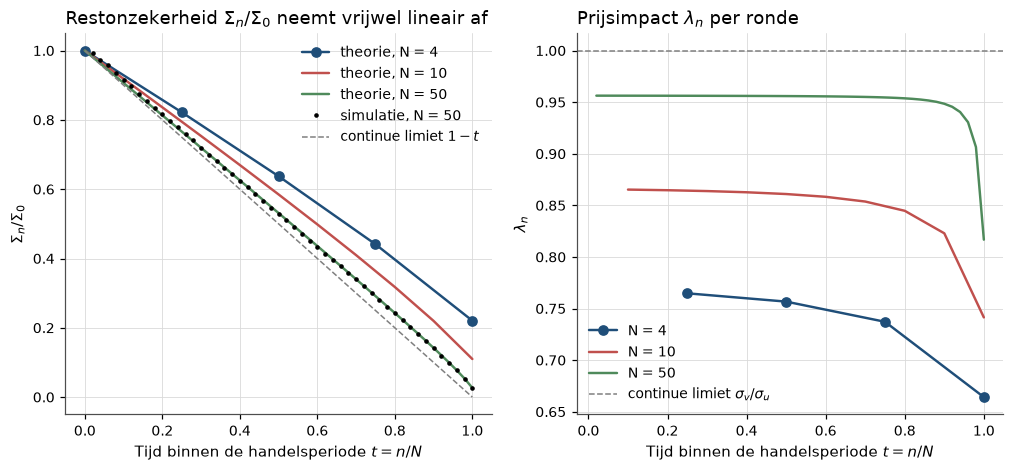

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for n, sol in solutions.items():
    if n == 1:
        continue
    t = np.r_[0, sol.index / n]
    axes[0].plot(t, np.r_[1.0, sol["Sigma"] / sol.attrs["Sigma_0"]], marker="o" if n == 4 else None, label=f"theorie, N = {n}")
    axes[1].plot(sol.index / n, sol["lambda"], marker="o" if n == 4 else None, label=f"N = {n}")
axes[0].plot(np.arange(1, N + 1) / N, resid_var / 1.0, "k.", ms=4, label="simulatie, N = 50")
axes[0].plot([0, 1], [1, 0], color="grey", ls="--", lw=1, label="continue limiet $1-t$")
axes[0].set_title("Restonzekerheid $\\Sigma_n/\\Sigma_0$ neemt vrijwel lineair af")
axes[0].set_xlabel("Tijd binnen de handelsperiode $t = n/N$")
axes[0].set_ylabel("$\\Sigma_n / \\Sigma_0$")
axes[0].legend()
axes[1].axhline(1.0, color="grey", ls="--", lw=1, label="continue limiet $\\sigma_v/\\sigma_u$")
axes[1].set_title("Prijsimpact $\\lambda_n$ per ronde")
axes[1].set_xlabel("Tijd binnen de handelsperiode $t = n/N$")
axes[1].set_ylabel("$\\lambda_n$")
axes[1].legend()
plt.show()

:::{figure} #cel-microstructuur-kyle-pad
:label: fig-microstructuur-kyle-pad
:width: 100%

Links: de restvariantie van $v$ gegeven de prijshistorie volgt al bij tien rondes
bijna de rechte lijn $1 - t$; de gesimuleerde punten voor $N = 50$ vallen op het
theoretische pad. De informatie komt dus niet in één keer en ook niet versneld aan
het eind in de prijs, maar in een constant tempo. Rechts: de prijsimpact is
vrijwel constant, behalve in de laatste rondes, waarin de insider zijn resterende
informatie opgebruikt.
:::

De restvariantie volgt het theoretische pad en opeenvolgende prijsveranderingen zijn
ongecorreleerd: de prijs is een martingaal ten opzichte van de order flow, ook al
handelt er iemand die de uitkomst kent. Wat de theorie niet noemt, is de spreiding:
de standaarddeviatie van de insiderwinst per markt is ongeveer even groot als haar
gemiddelde. Een insider met perfecte informatie heeft na twintig onafhankelijke
handelsdagen een $t$-waarde van ongeveer $\sqrt{20} \approx 4{,}5$; wie een klein
voordeel heeft met veel ruis rond elke positie, ziet het pas na jaren. Dat is het
2%-motief in microstructuurvorm: zelfs wie werkelijk iets weet, kan dat moeilijk
bewijzen.

### Een Glosten-Milgrom-sessie

We simuleren $5000$ handelsdagen, elk met $60$ opeenvolgende orders, in de markt
van het toy-voorbeeld ($V_H = 102$, $V_L = 98$, $\mu = 0{,}2$). De waarde wordt per
sessie getrokken; de market maker werkt na elke order zijn oordeel bij met Bayes.

In [6]:
n_sessions, n_trades = 5_000, 60
q_high, q_low = MU + (1 - MU) / 2, (1 - MU) / 2
is_high = rng.random(n_sessions) < 0.5
belief = np.full(n_sessions, 0.5)
spreads = np.empty((n_sessions, n_trades))
beliefs = np.empty((n_sessions, n_trades + 1))
beliefs[:, 0] = belief
for n in range(n_trades):
    bid, ask = gm_quotes(belief, MU, V_H, V_L)
    spreads[:, n] = ask - bid
    informed = rng.random(n_sessions) < MU
    buy = np.where(informed, is_high, rng.random(n_sessions) < 0.5)
    like_high = np.where(buy, q_high, 1 - q_high)
    like_low = np.where(buy, q_low, 1 - q_low)
    belief = belief * like_high / (belief * like_high + (1 - belief) * like_low)
    beliefs[:, n + 1] = belief

mid = V_L + (V_H - V_L) * beliefs
increments = np.diff(mid, axis=1)
pd.DataFrame(
    {
        "gemiddelde prijsverandering": [increments.mean(), increments[is_high].mean(), increments[~is_high].mean()],
        "autocorrelatie prijsveranderingen": [
            np.corrcoef(increments[:, 1:].ravel(), increments[:, :-1].ravel())[0, 1],
            np.nan,
            np.nan,
        ],
    },
    index=["alle sessies (publieke informatie)", "sessies met V = V_H", "sessies met V = V_L"],
).round(4)

,gemiddelde prijsverandering,autocorrelatie prijsveranderingen
alle sessies (publieke informatie),0.0001,0.0011
sessies met V = V_H,0.0275,NaN
sessies met V = V_L,-0.0275,NaN


Over alle sessies samen, dus vanuit het perspectief van iemand die $V$ niet kent,
is de gemiddelde prijsverandering nul en zijn opeenvolgende veranderingen
ongecorreleerd. Binnen sessies met een hoge waarde loopt de prijs voorspelbaar op,
binnen sessies met een lage waarde voorspelbaar af. Beide uitspraken zijn tegelijk
waar; de martingaaleigenschap is een eigenschap van een informatieverzameling, niet
van een prijspad.

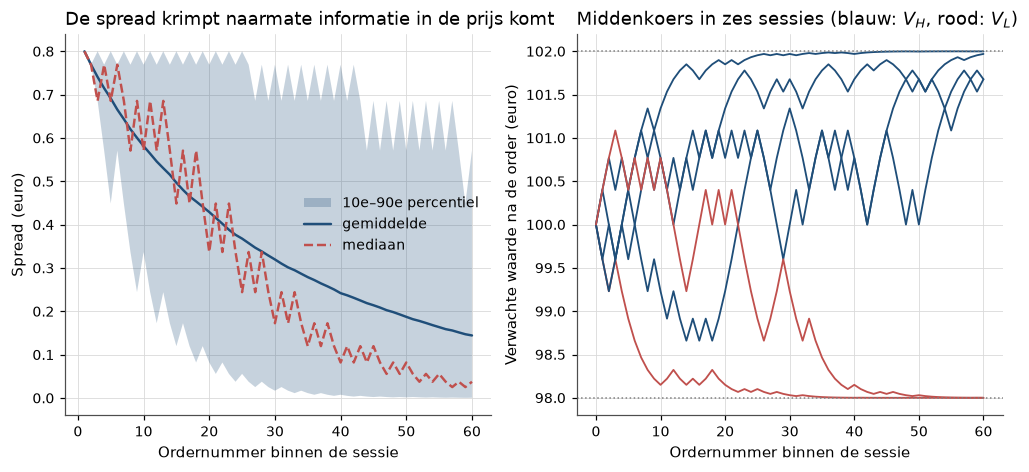

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
trade_no = np.arange(1, n_trades + 1)
axes[0].fill_between(trade_no, np.percentile(spreads, 10, axis=0), np.percentile(spreads, 90, axis=0),
                     alpha=0.25, label="10e–90e percentiel")
axes[0].plot(trade_no, spreads.mean(axis=0), label="gemiddelde")
axes[0].plot(trade_no, np.median(spreads, axis=0), ls="--", label="mediaan")
axes[0].set_title("De spread krimpt naarmate informatie in de prijs komt")
axes[0].set_xlabel("Ordernummer binnen de sessie")
axes[0].set_ylabel("Spread (euro)")
axes[0].legend()
for s in range(6):
    axes[1].plot(np.arange(n_trades + 1), mid[s], lw=1.2, color="C0" if is_high[s] else "C1")
axes[1].axhline(V_H, color="grey", ls=":", lw=1)
axes[1].axhline(V_L, color="grey", ls=":", lw=1)
axes[1].set_title("Middenkoers in zes sessies (blauw: $V_H$, rood: $V_L$)")
axes[1].set_xlabel("Ordernummer binnen de sessie")
axes[1].set_ylabel("Verwachte waarde na de order (euro)")
plt.show()

:::{figure} #cel-microstructuur-gm-spread
:label: fig-microstructuur-gm-spread
:width: 100%

Links: de spread begint op $\mu(V_H - V_L) = 0{,}80$ en krimpt naarmate de orders
één kant op wijzen; de brede percentielband laat zien hoe toevallig de snelheid van
prijsontdekking in één sessie is. Rechts: de middenkoers zwerft eerst en
convergeert dan naar de werkelijke waarde.
:::

### De Roll-schatter in eindige steekproeven

De Roll-maat schat een tweede moment, en tweede momenten zijn in deze reeks het
goed meetbare deel. Maar het signaal $-s^2/4$ is minuscuul naast de variantie van
de koersveranderingen. Bij een i.i.d.-benadering is de standaardfout van een
steekproefautocovariantie ongeveer $\Var(\Delta p)/\sqrt{T}$, dus de kans op een
positieve (en dus onbruikbare) schatting is ongeveer

```{math}
:label: eq-microstructuur-roll-kans
P\bigl(\widehat{\Cov} > 0\bigr) \approx \Phi\!\left(\sqrt{T}\,\rho_1\right),
\qquad \rho_1 = -\frac{s^2/4}{\sigma_e^2 + s^2/2}.
```

We simuleren het bid-ask-bounce-model voor een raster van verhoudingen
$s/\sigma_e$, met $T = 60$ (een kwartaal) en $T = 250$ (een jaar) handelsdagen, en
$4000$ steekproeven per punt.

In [8]:
def roll_positive_share(spread_ratio, n_days, n_samples=4_000):
    """Share of samples in which the Roll autocovariance is positive (sigma_e = 1)."""
    e = rng.normal(0.0, 1.0, (n_samples, n_days))
    q = rng.choice([-1.0, 1.0], (n_samples, n_days + 1))
    dp = e + spread_ratio / 2 * np.diff(q, axis=1)
    dp = dp - dp.mean(axis=1, keepdims=True)
    cov = (dp[:, 1:] * dp[:, :-1]).sum(axis=1) / (n_days - 1)
    return (cov > 0).mean()


ratios = np.geomspace(0.01, 3.0, 22)
roll_sim = pd.DataFrame(
    {T: [roll_positive_share(r, T) for r in ratios] for T in (60, 250)}, index=pd.Index(ratios, name="s / sigma")
)
roll_theory = pd.DataFrame(
    {T: stats.norm.cdf(np.sqrt(T) * -(ratios**2 / 4) / (1 + ratios**2 / 2)) for T in (60, 250)}, index=ratios
)
roll_sim.iloc[[0, 5, 10, 14, 17, 21]].round(3)

,60,250
s / sigma,,
0.010000,0.456,0.482
0.038886,0.437,0.474
0.151210,0.423,0.448
0.448140,0.336,0.206
1.012252,0.073,0.002
3.000000,0.000,0.000


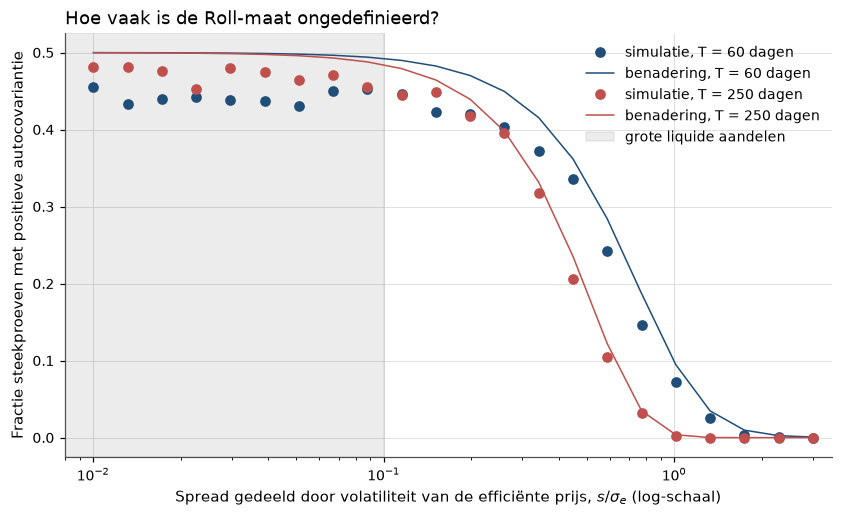

In [9]:
fig, ax = plt.subplots()
for i, T in enumerate((60, 250)):
    ax.plot(ratios, roll_sim[T], "o", color=f"C{i}", label=f"simulatie, T = {T} dagen")
    ax.plot(ratios, roll_theory[T], "-", color=f"C{i}", lw=1, label=f"benadering, T = {T} dagen")
ax.axvspan(0.003, 0.1, color="grey", alpha=0.15, label="grote liquide aandelen")
ax.set_xscale("log")
ax.set_xlim(0.008, 3.5)
ax.set_title("Hoe vaak is de Roll-maat ongedefinieerd?")
ax.set_xlabel("Spread gedeeld door volatiliteit van de efficiënte prijs, $s/\\sigma_e$ (log-schaal)")
ax.set_ylabel("Fractie steekproeven met positieve autocovariantie")
ax.legend()
plt.show()

:::{figure} #cel-microstructuur-roll-sim
:label: fig-microstructuur-roll-sim
:width: 90%

Voor grote liquide aandelen (spread van enkele basispunten, dagvolatiliteit van
1–2%, grijs gebied) is de Roll-maat in bijna de helft van de jaren ongedefinieerd,
ook als het model exact klopt. Pas als de spread in de buurt van de dagvolatiliteit
komt, wordt de schatter betrouwbaar. Een langere steekproef helpt, maar met een
factor $\sqrt{T}$: van een kwartaal naar een jaar verschuift de curve nauwelijks
een halve decade.
:::

Dit is motief 1 in een onverwachte vorm: varianties zijn goed meetbaar, maar niet als
het deel dat je zoekt een honderdduizendste van het totaal is. En de ruis is niet
symmetrisch: wie de Roll-maat alleen middelt over de jaren waarin ze bestaat,
overschat de spread systematisch.

## Replicatie op echte data

```{admonition} Replicatie
:class: seealso

**Bron.** Amihud, *Illiquidity and Stock Returns: Cross-Section and Time-Series
Effects*, Journal of Financial Markets 2002 {cite}`Amihud2002` (tijdreeksdeel,
model (11): onverwachte illiquiditeit tegen het gelijktijdige marktrendement), Roll,
*A Simple Implicit Measure of the Effective Bid-Ask Spread in an Efficient Market*,
Journal of Finance 1984 {cite}`Roll1984b`, en Pástor & Stambaugh, *Liquidity Risk
and Expected Stock Returns*, Journal of Political Economy 2003
{cite}`PastorStambaugh2003` (de crisismaanden in figuur 1, de correlatie met het
marktrendement, en de premie van liquiditeitsrisico).

**Data hier.** Dagelijkse gecorrigeerde slotkoersen en volumes van vijftig grote
Amerikaanse aandelen, 2002-01 t/m 2026-07, via `hap.data.yahoo(..., field="Volume")`
(dezelfde vijftig als in [](#03-14-roll) en [](#02-07-event-studies)); de maandelijkse
French-marktfactor en momentumfactor via `hap.data.french(...)`; de door Stambaugh
bijgehouden liquiditeitsreeksen 1962-08 t/m 2025-12 (niveau, innovatie en
verhandelbare factor) van zijn Wharton-pagina, gecachet met een kleine lokale loader.

**Verschil met het origineel.** Amihud en Roll gebruikten alle NYSE- (en AMEX-)
aandelen uit CRSP; Amihud werkte met jaren. Wij hebben vijftig aandelen die vandaag
groot zijn (survivorship, zie [](#02-05-crsp-tape)) en werken met maanden; Yahoo's
slotkoers is ook voor dividenden gecorrigeerd, zodat de vroege dollaromzet enkele
procenten te laag is. De Pástor-Stambaugh-maat bouwen we niet zelf na; hun
verhandelbare factor sorteert op historische in plaats van voorspelde bèta's en is
dus niet de 10-1-spread uit hun tabel 4.

**Verwachte afwijking.** Illiquiditeit piekt in de herfst van 2008 en in maart
2020. De innovatie in marktbrede illiquiditeit hangt *negatief* samen met het
gelijktijdige marktrendement, met een $t$-waarde ruim boven twee; dat teken moet
identiek zijn aan Amihud's $g_2 < 0$. De Roll-maat is voor een groot deel van de
aandeel-jaren ongedefinieerd, en waar ze wél bestaat, overschat ze de werkelijke
spread van deze aandelen (enkele basispunten) met een orde van grootte. De drie
diepste liquiditeitsmaanden uit het werkdocument van Pástor en Stambaugh (oktober
1987, november 1973, september 1998) moeten bij de laagste van hun bijgewerkte reeks
zitten, en de correlatie van $\mathcal{L}_t$ met het marktrendement over 1966–1999
moet dicht bij 0,36 liggen.
```

### Amihud en Roll per aandeel

In [10]:
TICKERS = [
    "AAPL", "ADBE", "AMZN", "ANET", "APH", "AVGO", "BAC", "BRK-B", "CMG", "CPRT",
    "CRM", "CSX", "CTAS", "CVX", "DE", "DHR", "DXCM", "EW", "FAST", "FTNT",
    "GILD", "GOOGL", "IDXX", "ISRG", "KO", "LRCX", "MA", "MNST", "NFLX", "NKE",
    "NOW", "NVDA", "ODFL", "ORLY", "PANW", "PG", "QCOM", "ROST", "SBUX", "SHW",
    "SMCI", "TJX", "TSCO", "TSLA", "UNH", "UNP", "V", "WFC", "WMT", "WRB",
]
prices = hap_data.yahoo(TICKERS, start="2002-01-01", end="2026-08-01")
volume = hap_data.yahoo(TICKERS, start="2002-01-01", end="2026-08-01", field="Volume")

returns = prices.pct_change(fill_method=None).loc["2002-01-03":]
dollar_volume_mln = (prices * volume).where(volume > 0).loc[returns.index] / 1e6
illiq_daily = returns.abs() / dollar_volume_mln * 1e4       # basis points per million dollars


def first_autocov(series, min_obs=100):
    """First-order autocovariance of a return series; NaN if fewer than min_obs observations."""
    x = series.dropna().to_numpy()
    return np.cov(x[1:], x[:-1])[0, 1] if len(x) > min_obs else np.nan


autocov_year = returns.groupby(returns.index.year).agg(first_autocov)
roll_year_bp = 2 * np.sqrt(-autocov_year.where(autocov_year < 0)) * 1e4

per_stock = pd.DataFrame(
    {
        "ILLIQ 2021–2026 (bp per $ mln)": illiq_daily.loc["2021":].mean(),
        "Roll-spread 2021–2026 (bp)": roll_year_bp.loc[2021:].median(),
        "fractie jaren Roll ongedefinieerd": (autocov_year >= 0).sum() / autocov_year.notna().sum(),
    }
).sort_values("ILLIQ 2021–2026 (bp per $ mln)")
print(f"aandeel-jaren met positieve autocovariantie: {(autocov_year >= 0).sum().sum()} van "
      f"{autocov_year.notna().sum().sum()} ({(autocov_year >= 0).sum().sum() / autocov_year.notna().sum().sum():.1%})")
per_stock.iloc[[0, 1, 2, 3, 4, -5, -4, -3, -2, -1]].round(3)

aandeel-jaren met positieve autocovariantie: 427 van 1168 (36.6%)


,ILLIQ 2021–2026 (bp per $ mln),Roll-spread 2021–2026 (bp),fractie jaren Roll ongedefinieerd
AAPL,0.010,62.395,0.600
TSLA,0.011,140.804,0.412
AMZN,0.017,119.360,0.520
NVDA,0.017,168.399,0.240
GOOGL,0.030,95.626,0.500
IDXX,0.598,109.359,0.360
ODFL,0.633,108.167,0.360
CPRT,0.694,76.554,0.560
WRB,1.389,64.045,0.320
SMCI,6.210,133.113,0.400


De ordening van ILLIQ is plausibel: Apple, Tesla, Amazon, Nvidia en Alphabet zijn
het diepst, de kleinere namen (Super Micro, W. R. Berkley, Copart) het ondiepst, met
ruim twee ordes van grootte ertussen. De Roll-maat vertelt een ander verhaal. Ruim
een derde van de aandeel-jaren heeft een positieve autocovariantie, in lijn met de
simulatie, en waar de maat bestaat, geeft ze spreads van zestig tot bijna
tweehonderd basispunten voor aandelen met een genoteerde spread van een of twee
basispunten. Roll's formule meet hier alle negatieve autocorrelatie in
dagrendementen, inclusief kortetermijnomkeringen, niet de bid-ask bounce.

In [11]:
by_year = pd.DataFrame(
    {
        "mediane Roll-spread (bp)": roll_year_bp.median(axis=1),
        "fractie ongedefinieerd": (autocov_year >= 0).sum(axis=1) / autocov_year.notna().sum(axis=1),
        "mediane ILLIQ (bp per $ mln)": illiq_daily.groupby(illiq_daily.index.year).mean().median(axis=1),
    }
)
by_year.round(3)

,mediane Roll-spread (bp),fractie ongedefinieerd,mediane ILLIQ (bp per $ mln)
date,,,
2002,147.796,0.324,4.133
2003,101.002,0.351,2.926
2004,58.434,0.447,2.468
2005,56.669,0.500,1.971
2006,59.755,0.548,1.669
2007,82.130,0.349,1.077
2008,186.869,0.159,1.586
2009,134.429,0.378,1.586
2010,81.669,0.340,0.868


In de tijd pikt de Roll-maat de crises wel op (de mediane "spread" is het hoogst in
2020 en 2008), vooral omdat volatiliteit en omkeringen dan toenemen. De mediane
ILLIQ daalt met ongeveer een factor dertig, omdat deze vijftig aandelen zo sterk
zijn gegroeid; een marktbrede tijdreeks moet die trend eerst verwijderen.

### Marktbrede illiquiditeit en het marktrendement

We nemen per aandeel per maand het gemiddelde van de dagelijkse ILLIQ (minstens 15
handelsdagen), trekken per aandeel het gemiddelde van de logaritme over de hele
periode af, zodat toe- en uittreders het niveau niet verschuiven, en middelen over
aandelen. De afwijking van het gemiddelde van de voorgaande twaalf maanden laat de
crisispieken zien. Daarna schatten we de maandelijkse versie van Amihud's model (11):
een AR(1) voor de marktilliquiditeit, en een regressie van het overrendement op de
markt op de vertraagde illiquiditeit en de innovatie, met Newey-West-standaardfouten.

In [12]:
days = illiq_daily.resample("ME").count()
log_illiq = np.log(illiq_daily.resample("ME").mean().where(days >= 15))
market_illiq = log_illiq.sub(log_illiq.mean()).mean(axis=1).rename("illiq")
deviation = (market_illiq - market_illiq.rolling(12).mean().shift(1)).rename("afwijking")

ar1 = hap.stats.newey_west(market_illiq, market_illiq.shift(1).rename("vertraagd"), lags=0)
innovation = (market_illiq - ar1.params["const"] - ar1.params["vertraagd"] * market_illiq.shift(1)).rename("innovatie")

ff3 = hap_data.market_monthly()
design = pd.concat([market_illiq.shift(1).rename("illiq vertraagd"), innovation], axis=1, sort=True)
amihud_fit = hap.stats.newey_west(ff3["Mkt-RF"].reindex(design.index), design, lags=3)

print(f"AR(1)-helling marktilliquiditeit: {ar1.params['vertraagd']:.3f}")
print("Hoogste afwijkingen van het voorgaande jaargemiddelde (log-punten):")
print(deviation.nlargest(6).round(2).to_string())
pd.DataFrame(
    {"coëfficiënt": amihud_fit.params, "NW-standaardfout": amihud_fit.bse, "t-waarde": amihud_fit.tvalues}
).round(4)

AR(1)-helling marktilliquiditeit: 0.986
Hoogste afwijkingen van het voorgaande jaargemiddelde (log-punten):
date
2020-03-31    0.93
2008-11-30    0.87
2008-10-31    0.80
2008-12-31    0.73
2020-04-30    0.51
2009-01-31    0.48


,coëfficiënt,NW-standaardfout,t-waarde
const,0.0081,0.0019,4.3451
illiq vertraagd,-0.0023,0.0019,-1.1941
innovatie,-0.1348,0.0171,-7.8672


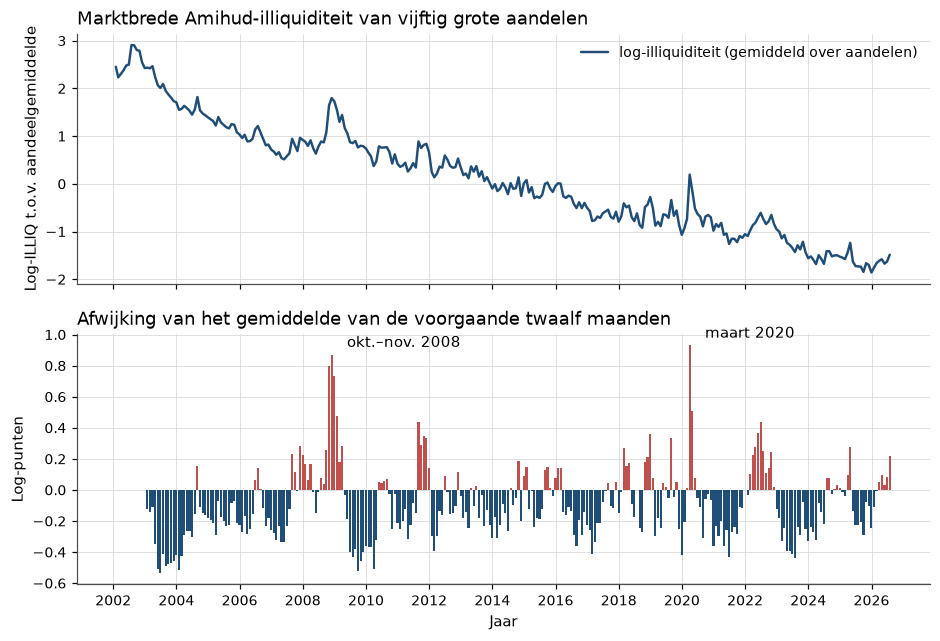

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6.5), sharex=True)
axes[0].plot(market_illiq.index, market_illiq, label="log-illiquiditeit (gemiddeld over aandelen)")
axes[0].set_title("Marktbrede Amihud-illiquiditeit van vijftig grote aandelen")
axes[0].set_ylabel("Log-ILLIQ t.o.v. aandeelgemiddelde")
axes[0].legend(loc="upper right")
axes[1].bar(deviation.index, deviation, width=25, color=np.where(deviation > 0, "C1", "C0"))
for date, text in [("2008-11-30", "okt.–nov. 2008"), ("2020-03-31", "maart 2020")]:
    axes[1].annotate(text, (pd.Timestamp(date), deviation.loc[date]), xytext=(10, 5), textcoords="offset points")
axes[1].set_title("Afwijking van het gemiddelde van de voorgaande twaalf maanden")
axes[1].set_ylabel("Log-punten")
hap.plotting.timeline_axis(axes[1], every=2)
axes[1].set_xlabel("Jaar")
plt.show()

:::{figure} #cel-microstructuur-amihud-tijd
:label: fig-microstructuur-amihud-tijd
:width: 100%

Boven: de illiquiditeit van deze vijftig aandelen daalt sterk over 25 jaar, een
weerspiegeling van hun groei. Onder: ten opzichte van hun eigen recente verleden
zijn maart 2020 en oktober–december 2008 de grootste uitschieters, gevolgd door
april 2020 en januari 2009. Liquiditeit verdwijnt precies in de maanden waarin
beleggers moesten verkopen.
:::

Het teken van Amihud's $g_2$ is gerepliceerd: een onverwachte stijging van de
marktilliquiditeit met één log-punt gaat samen met een overrendement dat ruim
13 procentpunt lager ligt in dezelfde maand, met een $t$-waarde van bijna $-8$. Dat
is een gelijktijdig verband, en een deel zit mechanisch in de constructie: een
koersdaling verhoogt $|r|$ en verlaagt de dollaromzet. Dat verwachte illiquiditeit
het *toekomstige* rendement verhoogt ($g_1 > 0$), repliceren we niet: de coëfficiënt
op de vertraagde illiquiditeit is klein, negatief en insignificant. Een voorspellend
verband voor het marktrendement vergt decennia om zichtbaar te worden
([](#04-20-voorspelbaarheid)); 24 jaar van vijftig overlevers is daarvoor te weinig.

### Pástor-Stambaugh

`hap.data` heeft geen loader voor de liquiditeitsreeksen van Pástor en Stambaugh.
Onderstaande functie haalt het tekstbestand eenmalig op en schrijft het via
`hap.cache.load_cached` weg naar `data/cache/`, zodat de lecture daarna met
`HAP_OFFLINE=1` draait.

In [14]:
PS_URL = "https://finance.wharton.upenn.edu/~stambaug/liq_data_1962_2025.txt"


def pastor_stambaugh_liquidity():
    """Pastor-Stambaugh (2003) monthly liquidity series, cached as a parquet snapshot.

    Columns: agg_liq (level, their Figure 1), innov_liq (innovation L_t, eq. 8) and
    traded_liq (value-weighted 10-1 portfolio on historical liquidity betas), decimals.
    """
    # TODO: naar hap.data (loader voor Stambaugh's Wharton-pagina)
    def build():
        text = requests.get(PS_URL, timeout=60).text
        rows = [line for line in text.splitlines() if line.strip() and not line.lstrip().startswith("%")]
        frame = pd.read_csv(io.StringIO("\n".join(rows)), sep=r"\s+", header=None,
                            names=["month", "agg_liq", "innov_liq", "traded_liq"])
        frame.index = pd.DatetimeIndex(
            pd.to_datetime(frame.pop("month").astype(str), format="%Y%m") + pd.offsets.MonthEnd(0), name="date"
        )
        return frame.mask(frame <= -99)

    return hap_cache.load_cached("pastor_stambaugh__liq_1962_2025", build)


ps = pastor_stambaugh_liquidity()
ps_market = pd.concat([ps, ff3["Mkt-RF"]], axis=1, sort=True).dropna(subset=["innov_liq", "Mkt-RF"])
print(f"reeks: {ps.index[0]:%Y-%m} t/m {ps.index[-1]:%Y-%m}")
print(f"correlatie L_t met Mkt-RF, 1966–1999: {ps_market.loc['1966':'1999', ['innov_liq', 'Mkt-RF']].corr().iloc[0, 1]:.2f}"
      f" (werkdocument: 0.36)")
print(f"correlatie L_t met Mkt-RF, 1962–2025: {ps_market[['innov_liq', 'Mkt-RF']].corr().iloc[0, 1]:.2f}")
both = pd.concat([ps["innov_liq"], innovation], axis=1, sort=True).dropna()
print(f"correlatie L_t met onze Amihud-innovatie, {both.index[0]:%Y}–{both.index[-1]:%Y}: {both.corr().iloc[0, 1]:.2f}")
ps["agg_liq"].nsmallest(6).rename("laagste liquiditeitsniveau").round(3).to_frame()

reeks: 1962-08 t/m 2025-12
correlatie L_t met Mkt-RF, 1966–1999: 0.35 (werkdocument: 0.36)
correlatie L_t met Mkt-RF, 1962–2025: 0.30
correlatie L_t met onze Amihud-innovatie, 2002–2025: -0.23


,laagste liquiditeitsniveau
date,
1987-10-31,-0.462
1973-11-30,-0.312
2008-12-31,-0.308
2002-10-31,-0.307
1998-09-30,-0.274
2008-03-31,-0.269


De drie maanden die het werkdocument als diepste noemt, oktober 1987, november 1973 en
september 1998, staan in de bijgewerkte reeks op plaats één, twee en vijf; december
2008 en oktober 2002 zijn erbij gekomen. De correlatie met het marktrendement over
1966–1999 is 0,35 tegen de gepubliceerde 0,36, met de French-marktfactor in plaats
van de NYSE-AMEX-index. Onze Amihud-innovatie correleert negatief met hun
liquiditeitsinnovatie, zoals het hoort voor een *il*liquiditeitsmaat, maar matig: de
maten meten verschillende dimensies van liquiditeit.

In [15]:
momentum = hap_data.french("F-F_Momentum_Factor")
factors4 = pd.concat([hap_data.french("F-F_Research_Data_Factors")[["Mkt-RF", "SMB", "HML"]], momentum],
                     axis=1, sort=True)
rows = {}
for start, end in [("1968", "2025"), ("1968", "2003"), ("2004", "2025")]:
    y = ps["traded_liq"].loc[start:end].dropna()
    fit = hap.stats.newey_west(y, factors4.reindex(y.index), lags=6)
    rows[f"{start}–{end}"] = {
        "maanden": len(y),
        "gemiddeld rendement (% p.j.)": 1200 * y.mean(),
        "vierfactor-alpha (% p.j.)": 1200 * fit.params["const"],
        "standaardfout alpha (% p.j.)": 1200 * fit.bse["const"],
        "t-waarde": fit.tvalues["const"],
    }
pd.DataFrame(rows).T.round(2)

,maanden,gemiddeld rendement (% p.j.),vierfactor-alpha (% p.j.),standaardfout alpha (% p.j.),t-waarde
1968–2025,696.0,3.57,3.59,1.74,2.06
1968–2003,432.0,5.18,5.40,1.99,2.72
2004–2025,264.0,0.93,-0.81,3.03,-0.27


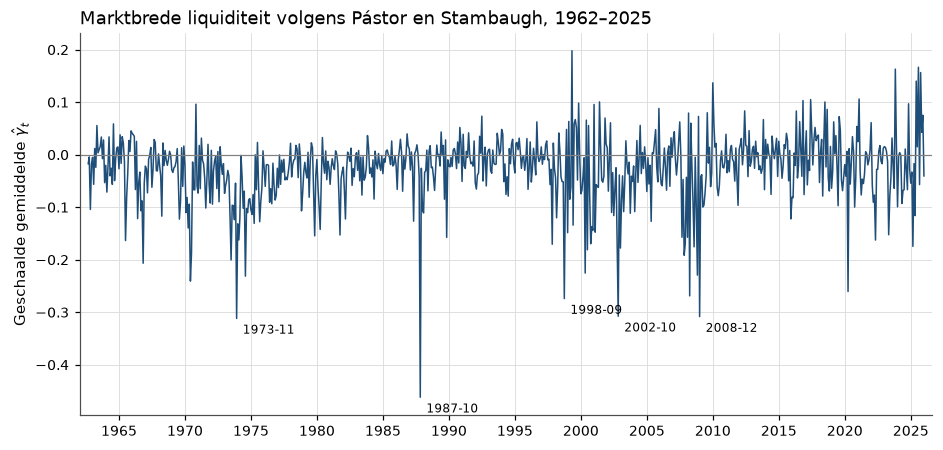

In [16]:
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(ps.index, ps["agg_liq"], lw=1)
for date in ps["agg_liq"].nsmallest(5).index:
    ax.annotate(f"{date:%Y-%m}", (date, ps.loc[date, "agg_liq"]), xytext=(4, -10), textcoords="offset points", fontsize=8)
ax.axhline(0, color="grey", lw=0.8)
ax.set_title("Marktbrede liquiditeit volgens Pástor en Stambaugh, 1962–2025")
ax.set_xlabel("Jaar")
ax.set_ylabel("Geschaalde gemiddelde $\\hat\\gamma_t$")
hap.plotting.timeline_axis(ax, every=5)
plt.show()

:::{figure} #cel-microstructuur-ps
:label: fig-microstructuur-ps
:width: 100%

De liquiditeitsreeks van Pástor en Stambaugh is meestal rustig en stort af en toe
diep in, bijna altijd in een maand die ook zonder deze maat als crisis bekendstaat.
Dat asymmetrische patroon, lange periodes van ruime liquiditeit en korte periodes
waarin ze verdwijnt, is precies wat van liquiditeit een risico maakt en niet alleen
een kost.
:::

De verhandelbare factor had over 1968–2025 een vierfactor-alpha van 3,6% per jaar
($t = 2{,}06$), minder dan de 7,5% uit het artikel, passend bij de eenvoudigere
sortering. Tot 2003, het jaar van publicatie, was de alpha 5,4% ($t = 2{,}72$);
sinds 2004 is ze $-0{,}8\%$ met een standaardfout van 3% per jaar. Dat laatste getal
is motief 1 in zijn zuiverste vorm: met 22 jaar data kunnen we een premie van 5% per
jaar noch aantonen noch uitsluiten. Stambaugh schrijft in de kop
van zijn bestand dat de factor *"a positive and significant alpha through 2025"*
heeft; dat klopt over de volledige periode, maar het rust op de eerste helft.

## Wat er brak, en wat daarna kwam

De microstructuurtheorie verklaart waarom er een spread is zonder dat iemand kosten
maakt, waarom grote orders de prijs bewegen, waarom prijzen een martingaal zijn ten
opzichte van publieke informatie terwijl insiders winst maken, en hoeveel private
informatie in de prijs komt: de helft in één ronde, alles bij doorlopende handel, in
een constant tempo. Ze gaf de efficiënte markt een mechanisme en Grossman-Stiglitz
een oplossing, en via Amihud, Pástor-Stambaugh en Acharya-Pedersen verbond ze de
handelsvloer met verwachte rendementen. De feiten zijn robuust: illiquiditeit piekt
in 2008 en maart 2020, en innovaties in illiquiditeit gaan samen met lage
gelijktijdige rendementen ($t$ bijna $-8$ in onze steekproef).

Waar het breekt, is de meting. De Roll-maat is in ruim een derde van de aandeel-jaren
ongedefinieerd en elders een orde van grootte te hoog; ILLIQ schat Kyle's $\lambda$
alleen onder aannames die in echte markten niet gelden; en de premie op
liquiditeitsrisico van Pástor en Stambaugh is in de twee decennia na publicatie in
hun eigen factor niet meer zichtbaar, met een standaardfout die te groot is om iets
uit te sluiten.

Is de liquiditeitspremie een risico of een vergissing? De Chicago-lezing is dat
illiquiditeit een kost is die rationele beleggers inprijzen, en liquiditeitsrisico een
toestandsvariabele die in slechte tijden toeslaat: wie illiquide activa houdt, levert
een verzekering aan de markt en krijgt daarvoor betaald. Het verdwijnen van de
factorpremie na 2003 kan dan een kleinere risicohoeveelheid zijn, of simpelweg ruis.
De Yale-lezing is dat illiquiditeit juist de *limits of arbitrage* uit
[](#04-23-behavioral) belichaamt: prijzen van illiquide activa wijken af omdat
arbitrageurs de posities niet kunnen innemen of volhouden, en de premie verdwijnt
zodra genoeg kapitaal de kans ziet, zoals McLean en Pontiff voor gepubliceerde
anomalieën in het algemeen vonden (zie [](#06-34-factor-zoo)). Data die de lezingen
zou scheiden, bestaat in principe: een risicopremie wordt in crises *betaald*, een
vergissing verdwijnt na publicatie. Onze replicatie laat beide zien, het eerste in de
regressie, het tweede in de subperiodes, en beslecht de vraag dus niet. Santa-Clara's praktijkles past op
beide lezingen: wie illiquide activa houdt, *"should not assume he can sell them at
the price in the last valuation report"* {cite}`SantaClara2026`.

Wat er daarna kwam, is de vraag wie die handelskosten eigenlijk betaalt en wie
eraan verdient: de beleggingsindustrie, van actieve fondsen die hun informatievoordeel
in Kyle's zin moeten terugverdienen tot de indexfondsen die handel minimaliseren, in
[](#04-25-industrie).

## Oefeningen

:::{exercise}
:label: ex-microstructuur-1

**De spread na een reeks orders.** Neem de Glosten-Milgrom-markt met $V_H = 102$,
$V_L = 98$ en prior $\pi_0 = \tfrac12$.

1. Laat met [](#eq-microstructuur-gm-spread) zien dat de spread maximaal is bij
   $\pi = \tfrac12$, en bereken hem bij $\mu = 0{,}2$ en $\mu = 0{,}5$.
2. Bij $\mu = 0{,}5$ komen er drie kooporders achter elkaar. Bereken met de hand het
   oordeel $\pi_3$ en de bied- en laatkoers na elke order, en controleer met code.
3. Hoeveel kooporders achter elkaar zijn er bij $\mu = 0{,}2$ nodig voordat de
   spread onder $0{,}10$ euro zakt?
:::

:::{solution} ex-microstructuur-1
:class: dropdown

**(1)** Schrijf $z = (2\pi-1)^2$; dan is $4\pi(1-\pi) = 1 - z$ en de spread
$\mu\Delta V(1-z)/(1-\mu^2 z)$, dalend in $z$ omdat $\mu^2 < 1$. Het maximum ligt bij
$z = 0$, dus $\pi = \tfrac12$, met spread $\mu\Delta V$: $0{,}80$ voor $\mu = 0{,}2$
en $2{,}00$ voor $\mu = 0{,}5$.

**(2)** Bij $\mu = 0{,}5$ is $q_H = 0{,}75$ en $q_L = 0{,}25$, dus de likelihoodratio
van een koop is 3. De odds $\pi/(1-\pi)$ worden per koop verdrievoudigd: 1, 3, 9,
27, dus $\pi_1 = 0{,}75$, $\pi_2 = 0{,}9$, $\pi_3 = 27/28 = 0{,}9643$.

In [17]:
belief_path, rows = 0.5, []
for k in range(1, 4):
    b, a = gm_quotes(belief_path, 0.5, V_H, V_L)
    belief_path = belief_path * 0.75 / (belief_path * 0.75 + (1 - belief_path) * 0.25)
    rows.append({"order": k, "bid vóór order": b, "ask vóór order": a, "oordeel na koop": belief_path})
print(pd.DataFrame(rows).round(4).to_string(index=False))

belief_path, n_buys = 0.5, 0
while np.subtract(*gm_quotes(belief_path, 0.2, V_H, V_L)[::-1]) >= 0.10:
    belief_path = belief_path * 0.6 / (belief_path * 0.6 + (1 - belief_path) * 0.4)
    n_buys += 1
print(f"\n(3) bij mu = 0.2: spread onder 0.10 na {n_buys} kooporders op rij (oordeel {belief_path:.4f})")

 order  bid vóór order  ask vóór order  oordeel na koop
     1            99.0        101.0000           0.7500
     2           100.0        101.6000           0.9000
     3           101.0        101.8571           0.9643

(3) bij mu = 0.2: spread onder 0.10 na 9 kooporders op rij (oordeel 0.9746)


**(3)** Elke koop vermenigvuldigt de odds met $1{,}5$; de spread zakt onder $0{,}10$
zodra $\pi(1-\pi)$ klein genoeg is, wat de code hierboven uitrekent. De oefening laat
zien dat de snelheid van prijsontdekking in Glosten-Milgrom niet door de spread zelf
wordt bepaald, maar door de informatieve waarde van één order, de likelihoodratio
$q_H/q_L = (1+\mu)/(1-\mu)$.
:::

:::{exercise}
:label: ex-microstructuur-2

**Meer ruis, zelfde informatie.** In de Kyle-markt met één ronde uit het
toy-voorbeeld ($\sigma_v = 4$) verdubbelt het volume van de noise traders naar
$\sigma_u = 20\,000$.

1. Bereken $\beta$, $\lambda$, de verwachte insiderwinst en $\Var(v\mid p)$, en
   vergelijk met $\sigma_u = 10\,000$.
2. Simuleer $200\,000$ markten voor beide waarden van $\sigma_u$ en controleer de vier
   grootheden.
3. Een toezichthouder kijkt naar de winst van de insider over twintig onafhankelijke
   handelsdagen. Wat is de verwachte $t$-waarde van de gemiddelde dagwinst, en hangt
   die af van $\sigma_u$?
:::

:::{solution} ex-microstructuur-2
:class: dropdown

**(1)** $\beta = 20\,000/4 = 5000$, $\lambda = 4/40\,000 = 0{,}0001$, verwachte winst
$\tfrac12\cdot4\cdot20\,000 = 40\,000$, en $\Var(v\mid p) = 8$, ongewijzigd. De
insider handelt twee keer zo agressief, de markt is twee keer zo diep, hij verdient
twee keer zoveel, en de prijs is precies even informatief.

**(2) en (3)**

In [18]:
n_markets = 200_000
rows = {}
for s_u in (10_000.0, 20_000.0):
    b_k, l_k = s_u / 4.0, 4.0 / (2 * s_u)
    v_sim = rng.normal(0.0, 4.0, n_markets)
    u_sim = rng.normal(0.0, s_u, n_markets)
    y_sim = b_k * v_sim + u_sim
    p_sim = l_k * y_sim
    gain = b_k * v_sim * (v_sim - p_sim)
    slope = np.cov(v_sim, y_sim)[0, 1] / np.var(y_sim)
    rows[f"sigma_u = {s_u:,.0f}"] = {
        "lambda (regressie v op y)": slope,
        "gemiddelde winst insider": gain.mean(),
        "Var(v | p)": np.var(v_sim - p_sim),
        "t-waarde na 20 dagen": np.sqrt(20) * gain.mean() / gain.std(),
    }
pd.DataFrame(rows).round(5)

,"sigma_u = 10,000","sigma_u = 20,000"
lambda (regressie v op y),0.00020,0.00010
gemiddelde winst insider,19899.05754,39903.05351
Var(v | p),7.97848,7.99512
t-waarde na 20 dagen,2.57547,2.59527


De winst van de insider en haar standaarddeviatie schalen allebei met $\sigma_u$,
zodat de $t$-waarde na twintig dagen (ongeveer 2,6) niet van $\sigma_u$ afhangt. Een
insider in een drukke markt verdient meer, maar valt statistisch niet meer op.
:::

:::{exercise}
:label: ex-microstructuur-3

**Hoe stabiel is de liquiditeitspremie?** Gebruik de verhandelbare factor
`ps["traded_liq"]` en de vier factoren `factors4`.

1. Schat de vierfactor-alpha in voortschrijdende vensters van tien jaar (120 maanden),
   met Newey-West-standaardfouten (6 lags), en rapporteer per venster de alpha en een
   95%-betrouwbaarheidsinterval in procent per jaar.
2. In hoeveel procent van de vensters is de alpha significant positief? Hoeveel
   vensters van tien jaar zou je nodig hebben om een ware alpha van 3% per jaar met
   $t = 2$ te zien, gegeven de residuele volatiliteit?
:::

:::{solution} ex-microstructuur-3
:class: dropdown

In [19]:
traded = ps["traded_liq"].dropna()
window_rows = []
for end in range(120, len(traded) + 1, 12):
    y = traded.iloc[end - 120:end]
    fit = hap.stats.newey_west(y, factors4.reindex(y.index), lags=6)
    alpha_ann, se_ann = 1200 * fit.params["const"], 1200 * fit.bse["const"]
    window_rows.append({"venster eindigt": f"{y.index[-1]:%Y-%m}", "alpha (% p.j.)": alpha_ann,
                        "ondergrens 95%": alpha_ann - 1.96 * se_ann, "bovengrens 95%": alpha_ann + 1.96 * se_ann})
windows = pd.DataFrame(window_rows).set_index("venster eindigt")

full_fit = hap.stats.newey_west(traded, factors4.reindex(traded.index), lags=6)
resid_vol_ann = np.sqrt(12) * full_fit.resid.std()
years_needed = (2 * resid_vol_ann / 0.03) ** 2
print(f"fractie vensters met ondergrens > 0: {(windows['ondergrens 95%'] > 0).mean():.0%}")
print(f"residuele volatiliteit: {resid_vol_ann:.1%} per jaar; jaren nodig voor t = 2 bij alpha = 3%: {years_needed:.0f}")
windows.iloc[::5].round(2)

fractie vensters met ondergrens > 0: 20%
residuele volatiliteit: 12.6% per jaar; jaren nodig voor t = 2 bij alpha = 3%: 71


,alpha (% p.j.),ondergrens 95%,bovengrens 95%
venster eindigt,,,
1977-12,2.81,-5.08,10.70
1982-12,4.68,-2.42,11.78
1987-12,4.39,-1.55,10.34
1992-12,2.02,-4.47,8.51
1997-12,3.84,-4.65,12.33
2002-12,8.00,0.61,15.39
2007-12,14.81,8.40,21.22
2012-12,4.28,-4.81,13.38
2017-12,-6.20,-14.40,2.00


De betrouwbaarheidsintervallen van tien jaar zijn ongeveer vijftien procentpunt
breed, en slechts een vijfde van de vensters ligt volledig boven nul. Met de
residuele volatiliteit van de factor is ruim zeventig jaar nodig om een premie van
3% per jaar met $t = 2$ te zien. De oefening laat zien dat "liquiditeitsrisico is geprijsd"
een uitspraak is die op het gemiddelde van een halve eeuw rust, en dat geen enkel
decennium op zich haar kan bevestigen of weerleggen.
:::